In [ ]:
# Design an MLP classifier and do experiment using TrainingSet-1 for training and using TestSet-1 for testing. 
# You should draw the learning curve, calculate the training error, cross-validation error on the training set, and the test error. 
# Try different choices in the model design and/or hyper-parameter setting and observe their influence on the training procedure as well as the model performance.

In [165]:
## in terminal after creating a virtual env
# pip install --upgrade pip
# pip --version
# pip install numpy matplotlib pandas scikit-learn seaborn

In [166]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
from sklearn.neural_network import MLPClassifier

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html
from sklearn.model_selection import learning_curve

# Read files

In [167]:
# trainingset

x1_train = pd.read_csv("/Users/kellyt/Documents/ml/HW2/train1_icu_data.csv")
y1_train = pd.read_csv("/Users/kellyt/Documents/ml/HW2/train1_icu_label.csv")

In [168]:
# testset

x1_test = pd.read_csv("/Users/kellyt/Documents/ml/HW2/test1_icu_data.csv")
y1_test = pd.read_csv("/Users/kellyt/Documents/ml/HW2/test1_icu_label.csv")

In [169]:
# A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

y1_train = y1_train.values.ravel()
y1_test = y1_test.values.ravel()

In [170]:
# print("x1_train:", x1_train.shape)
print("y1_train:", y1_train.shape)

print("x1_test:", x1_test.shape)
print("y1_test:", y1_test.shape)

# print("training distribution", y1_train.value_counts(normalize=True))
# print("testing distribution", y1_test.value_counts(normalize=True))

y1_train: (5000,)
x1_test: (1097, 108)
y1_test: (1097,)


In [171]:
x1_train

,age,bmi,elective_surgery,height,pre_icu_los_days,weight,apache_2_diagnosis,apache_3j_diagnosis,arf_apache,bun_apache,...,apache_2_bodysystem_Cardiovascular,apache_2_bodysystem_Gastrointestinal,apache_2_bodysystem_Haematologic,apache_2_bodysystem_Metabolic,apache_2_bodysystem_Neurologic,apache_2_bodysystem_Renal/Genitourinary,apache_2_bodysystem_Respiratory,apache_2_bodysystem_Trauma,apache_2_bodysystem_Undefined Diagnoses,apache_2_bodysystem_Undefined diagnoses
0,74.0,29.681633,0,175.0,0.184722,90.90,108.0,203.01,0.0,26.0,...,0,0,0,0,0,0,1,0,0,0
1,48.0,37.521259,0,168.0,1.993056,105.90,113.0,501.05,0.0,40.0,...,1,0,0,0,0,0,0,0,0,0
2,38.0,21.300161,0,165.1,0.370833,58.06,304.0,301.01,0.0,34.0,...,0,1,0,0,0,0,0,0,0,0
3,84.0,20.792690,0,154.9,0.306944,49.89,113.0,502.01,0.0,34.0,...,1,0,0,0,0,0,0,0,0,0
4,58.0,29.161731,0,162.6,26.084722,77.10,301.0,410.01,0.0,14.0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,47.0,21.671258,0,165.0,0.075694,59.00,114.0,102.01,0.0,28.0,...,1,0,0,0,0,0,0,0,0,0
4996,77.0,28.824870,0,170.2,2.109028,83.50,301.0,410.01,1.0,48.0,...,0,0,0,0,1,0,0,0,0,0
4997,62.0,27.267401,0,177.8,0.119444,86.20,119.0,601.04,0.0,18.0,...,0,0,0,0,0,0,0,1,0,0
4998,61.0,27.996500,0,190.5,0.010417,101.60,304.0,313.05,1.0,101.0,...,0,1,0,0,0,0,0,0,0,0


In [172]:
y1_train

array([1, 1, 1, ..., 1, 1, 0])

# Build MLP classifier

In [ ]:
mlp_clf_8 = MLPClassifier(hidden_layer_sizes=(8,), random_state=42, max_iter=300).fit(x1_train, y1_train) # input -> 8 hidden layers -> output
mlp_clf_16 = MLPClassifier(hidden_layer_sizes=(16,), random_state=42, max_iter=300).fit(x1_train, y1_train) # input -> 16 hidden layers -> output
mlp_clf_32 = MLPClassifier(hidden_layer_sizes=(32,), random_state=42, max_iter=300).fit(x1_train, y1_train) # input -> 32 hidden layers -> output

mlp_clf_16_8 = MLPClassifier(hidden_layer_sizes=(16, 8), random_state=42, max_iter=300).fit(x1_train, y1_train) # input -> 16 hidden layers -> 8 hidden layers -> output

/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203

MLP Classifier with hidden layers (8,):
Training Accuracy: 0.7746
Testing Accuracy: 0.7840



/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.ve

MLP Classifier with hidden layers (16,):
Training Accuracy: 0.7766
Testing Accuracy: 0.7612



/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.ve

MLP Classifier with hidden layers (32,):
Training Accuracy: 0.7808
Testing Accuracy: 0.7712

MLP Classifier with hidden layers (16, 8):
Training Accuracy: 0.7918
Testing Accuracy: 0.7666



/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## Training error

In [174]:
train_mlp_8_prob = mlp_clf_8.predict_proba(x1_train)
print("ML classifier w/ 8 hidden layers", train_mlp_8_prob[:1])
train_mlp_16_prob = mlp_clf_16.predict_proba(x1_train)
print("ML classifier w/ 16 hidden layers", train_mlp_16_prob[:1])
train_mlp_32_prob = mlp_clf_32.predict_proba(x1_train)
print("ML classifier w/ 32 hidden layers", train_mlp_32_prob[:1])

train_mlp_16_8_prob = mlp_clf_16_8.predict_proba(x1_train)
print("ML classifier w/ 16 and 8 hidden layers", train_mlp_16_8_prob[:1])

ML classifier w/ 8 hidden layers [[0.04435118 0.95564882]]
ML classifier w/ 16 hidden layers [[0.04522593 0.95477407]]
ML classifier w/ 32 hidden layers [[0.02628957 0.97371043]]
ML classifier w/ 16 and 8 hidden layers [[0.06549506 0.93450494]]


/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.ve

In [175]:
train_mlp_8_predict = mlp_clf_8.predict(x1_train)
print("ML classifier w/ 8 hidden layers", train_mlp_8_predict)
train_mlp_16_predict = mlp_clf_16.predict(x1_train)
print("ML classifier w/ 16 hidden layers", train_mlp_16_predict)
train_mlp_32_predict = mlp_clf_32.predict(x1_train)
print("ML classifier w/ 32 hidden layers", train_mlp_32_predict)  

train_mlp_16_8_predict = mlp_clf_16_8.predict(x1_train)
print("ML classifier w/ 16 and 8 hidden layers", train_mlp_16_8_predict)

ML classifier w/ 8 hidden layers [1 1 1 ... 0 1 0]
ML classifier w/ 16 hidden layers [1 1 1 ... 1 1 0]
ML classifier w/ 32 hidden layers [1 1 1 ... 1 1 0]
ML classifier w/ 16 and 8 hidden layers [1 1 1 ... 1 1 0]


/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.ve

In [176]:
train_accuracy = accuracy_score(
    y1_train,
    train_mlp_16_8_predict
)

train_error = 1 - train_accuracy

print("Training Accuracy:", train_accuracy)
print("Training Error:", train_error)

Training Accuracy: 0.7918
Training Error: 0.20820000000000005


### Cross validation error

In [183]:
# Cross-validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    MLPClassifier(
        hidden_layer_sizes=(16,),
        random_state=42,
        max_iter=300
    ),
    x1_train,
    y1_train,
    cv=cv,
    scoring='accuracy'
)

cv_error = 1 - cv_scores.mean()
print("CV Scores:", cv_scores)
print("CV Error:", cv_error)

/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.ve

CV Scores: [0.765 0.764 0.752 0.761 0.784]
CV Error: 0.23480000000000012


/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### Learning Curve

/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.ve

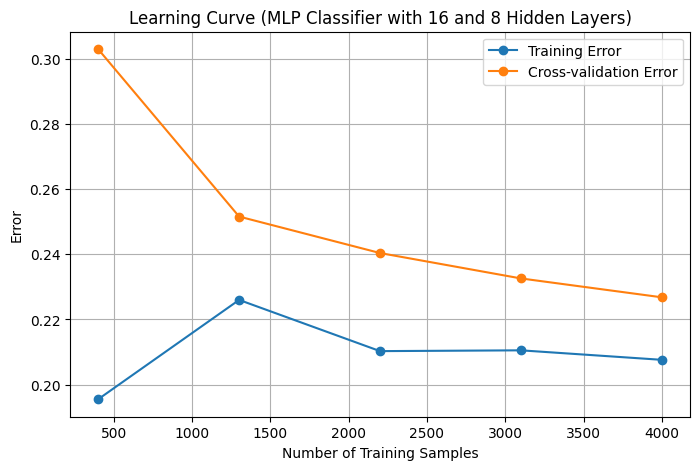

In [185]:
train_sizes, train_scores, validation_scores = learning_curve(
    mlp_clf_16_8,
    x1_train,
    y1_train,
    cv=cv,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Convert accuracy to error
train_errors = 1 - train_scores.mean(axis=1)
validation_errors = 1 - validation_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_errors,
    marker='o',
    label='Training Error'
)

plt.plot(
    train_sizes,
    validation_errors,
    marker='o',
    label='Cross-validation Error'
)

plt.xlabel("Number of Training Samples")
plt.ylabel("Error")
plt.title("Learning Curve (MLP Classifier with 16 and 8 Hidden Layers)")
plt.legend()
plt.grid()

plt.show()

## Test error

In [177]:
test_mlp_8_prob = mlp_clf_8.predict_proba(x1_test)
print("ML classifier w/ 8 hidden layers", test_mlp_8_prob[:1])
test_mlp_16_prob = mlp_clf_16.predict_proba(x1_test)
print("ML classifier w/ 16 hidden layers", test_mlp_16_prob[:1])
test_mlp_32_prob = mlp_clf_32.predict_proba(x1_test)
print("ML classifier w/ 32 hidden layers", test_mlp_32_prob[:1])

test_mlp_16_8_prob = mlp_clf_16_8.predict_proba(x1_test)
print("ML classifier w/ 16 and 8 hidden layers", test_mlp_16_8_prob[:1])

ML classifier w/ 8 hidden layers [[0.84444728 0.15555272]]
ML classifier w/ 16 hidden layers [[0.97001818 0.02998182]]
ML classifier w/ 32 hidden layers [[0.99386754 0.00613246]]
ML classifier w/ 16 and 8 hidden layers [[0.91548776 0.08451224]]


/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.ve

In [178]:
test_mlp_8_predict = mlp_clf_8.predict(x1_test)
print("ML classifier w/ 8 hidden layers", test_mlp_8_predict)
test_mlp_16_predict = mlp_clf_16.predict(x1_test)
print("ML classifier w/ 16 hidden layers", test_mlp_16_predict)
test_mlp_32_predict = mlp_clf_32.predict(x1_test)
print("ML classifier w/ 32 hidden layers", test_mlp_32_predict)  

test_mlp_16_8_predict = mlp_clf_16_8.predict(x1_test)
print("ML classifier w/ 16 and 8 hidden layers", test_mlp_16_8_predict)

ML classifier w/ 8 hidden layers [0 0 0 ... 1 1 0]
ML classifier w/ 16 hidden layers [0 1 1 ... 1 1 1]
ML classifier w/ 32 hidden layers [0 0 1 ... 1 1 1]
ML classifier w/ 16 and 8 hidden layers [0 1 1 ... 1 1 0]


/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.ve

In [ ]:
# print("MLP 8 hidden layers score for test set:", mlp_clf_8.score(x1_test, y1_test))
# print("MLP 16 hidden layers score for test set:", mlp_clf_16.score(x1_test, y1_test))
# print("MLP 32 hidden layers score for test set:", mlp_clf_32.score(x1_test, y1_test))

# print("MLP 16 and 8 hidden layers score:", mlp_clf_16_8.score(x1_test, y1_test))

MLP 8 hidden layers score for test set: 0.7839562443026435
MLP 16 hidden layers score for test set: 0.7611668185961714
MLP 32 hidden layers score for test set: 0.7711941659070192
MLP 16 and 8 hidden layers score: 0.7666362807657247


/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kellyt/Documents/ml/.ve

# Model Performance

In [ ]:
print("Test Accuracy:", 
      accuracy_score(y1_test, test_mlp_16_8_predict))

test_error = 1 - accuracy_score(y1_test, test_mlp_16_8_predict)
print("Test Error:", test_error)

print("Test Precision:",
      precision_score(y1_test, test_mlp_16_8_predict))

print("Test Recall:",
      recall_score(y1_test, test_mlp_16_8_predict))

print("TestF1:",
      f1_score(y1_test, test_mlp_16_8_predict))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y1_test, test_mlp_16_8_predict))

print("\nClassification Report:")
print(classification_report(y1_test, test_mlp_16_8_predict))

Test Accuracy: 0.7666362807657247
Test Error: 0.23336371923427535
Test Precision: 0.7365853658536585
Test Recall: 0.8281535648994516
TestF1: 0.7796901893287436

Test Confusion Matrix:
[[388 162]
 [ 94 453]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.71      0.75       550
           1       0.74      0.83      0.78       547

    accuracy                           0.77      1097
   macro avg       0.77      0.77      0.77      1097
weighted avg       0.77      0.77      0.77      1097



# MLP classifier (for loop to test parameters)

MLP Classifier with hidden layers (8,):
Training Accuracy: 0.5532
Training Error: 0.4468
Testing Accuracy: 0.5351

Test Error: 0.4649
Test Precision: 0.5343
Test Recall: 0.5265
Test F1-Score: 0.5304

Test Confusion Matrix:
[[299 251]
 [259 288]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.54      0.54       550
           1       0.53      0.53      0.53       547

    accuracy                           0.54      1097
   macro avg       0.54      0.54      0.54      1097
weighted avg       0.54      0.54      0.54      1097

Cross-validation Scores: [0.543 0.553 0.514 0.56  0.583]
Cross-validation Error: 0.4494


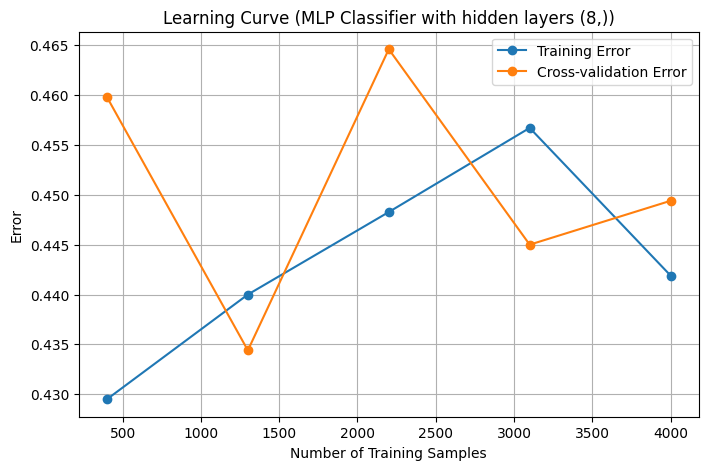

MLP Classifier with hidden layers (16,):
Training Accuracy: 0.7418
Training Error: 0.2582
Testing Accuracy: 0.7402

Test Error: 0.2598
Test Precision: 0.7266
Test Recall: 0.7678
Test F1-Score: 0.7467

Test Confusion Matrix:
[[392 158]
 [127 420]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.71      0.73       550
           1       0.73      0.77      0.75       547

    accuracy                           0.74      1097
   macro avg       0.74      0.74      0.74      1097
weighted avg       0.74      0.74      0.74      1097

Cross-validation Scores: [0.74  0.767 0.743 0.722 0.769]
Cross-validation Error: 0.2518


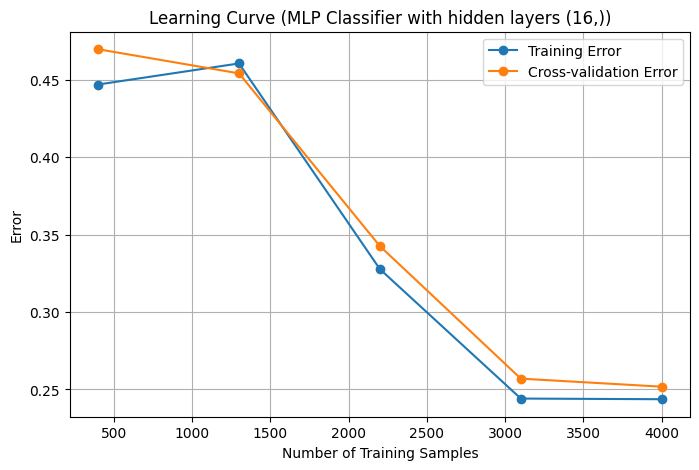

MLP Classifier with hidden layers (32,):
Training Accuracy: 0.7722
Training Error: 0.2278
Testing Accuracy: 0.7703

Test Error: 0.2297
Test Precision: 0.7574
Test Recall: 0.7934
Test F1-Score: 0.7750

Test Confusion Matrix:
[[411 139]
 [113 434]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.77       550
           1       0.76      0.79      0.78       547

    accuracy                           0.77      1097
   macro avg       0.77      0.77      0.77      1097
weighted avg       0.77      0.77      0.77      1097

Cross-validation Scores: [0.769 0.743 0.745 0.74  0.751]
Cross-validation Error: 0.2504


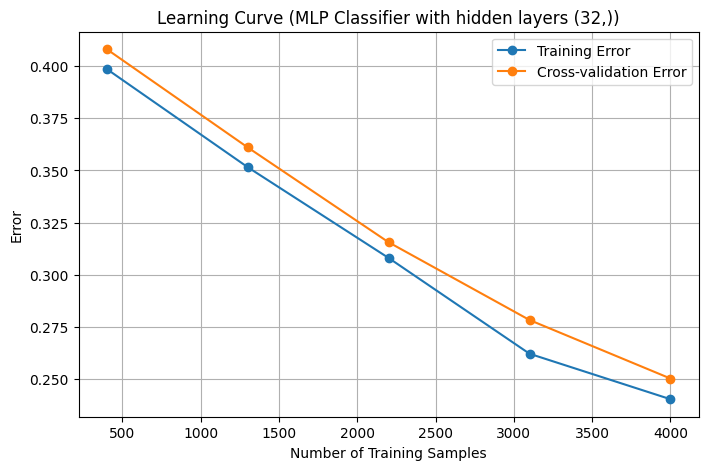

MLP Classifier with hidden layers (16, 8):
Training Accuracy: 0.7380
Training Error: 0.2620
Testing Accuracy: 0.7201

Test Error: 0.2799
Test Precision: 0.7041
Test Recall: 0.7569
Test F1-Score: 0.7295

Test Confusion Matrix:
[[376 174]
 [133 414]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.68      0.71       550
           1       0.70      0.76      0.73       547

    accuracy                           0.72      1097
   macro avg       0.72      0.72      0.72      1097
weighted avg       0.72      0.72      0.72      1097

Cross-validation Scores: [0.74  0.727 0.741 0.767 0.769]
Cross-validation Error: 0.2512


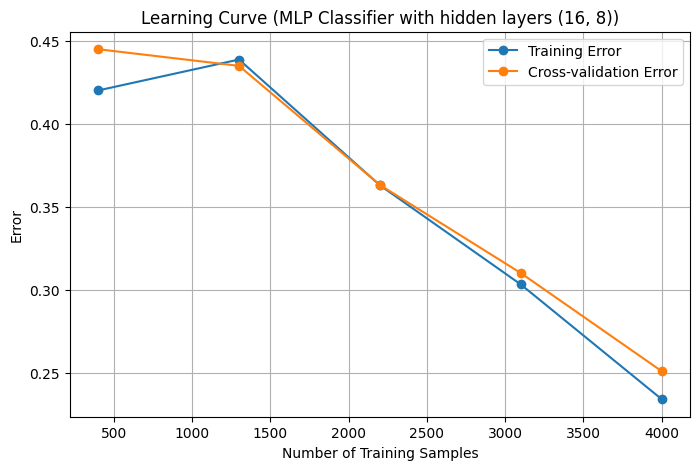

In [203]:
import warnings

hidden_layer_sizes = [(8,), (16,), (32,), (16, 8)]

for hidden_layers in hidden_layer_sizes:
    warnings.simplefilter("ignore")
    warnings.filterwarnings('ignore')  # Catches ConvergenceWarning and others
    np.seterr(all='ignore')

    mlp_clf = MLPClassifier(hidden_layer_sizes=hidden_layers, activation='relu', random_state=42, max_iter=500, early_stopping=True,)

    mlp_clf.fit(x1_train, y1_train)

    mlp_prob = mlp_clf.predict_proba(x1_train)
    mlp_predict = mlp_clf.predict(x1_train)
    test_mlp_prob = mlp_clf.predict_proba(x1_test)
    test_mlp_predict = mlp_clf.predict(x1_test)
    # print(f"Probabilities for MLP Classifier with hidden layers {hidden_layers}:", mlp_prob[:5])
    # print(f"Predictions for MLP Classifier with hidden layers {hidden_layers}:", mlp_predict[:5])

    train_score = mlp_clf.score(x1_train, y1_train)
    test_score = mlp_clf.score(x1_test, y1_test)

    train_accuracy = accuracy_score(y1_train, mlp_predict)
    train_error = 1 - train_score
    test_accuracy = accuracy_score(y1_test, test_mlp_predict)
    test_error = 1 - test_accuracy

    test_precision = precision_score(y1_test, test_mlp_predict)
    test_recall = recall_score(y1_test, test_mlp_predict)
    test_f1 = f1_score(y1_test, test_mlp_predict)


    print(f"MLP Classifier with hidden layers {hidden_layers}:")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Training Error: {train_error:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}\n")
    print(f"Test Error: {test_error:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1-Score: {test_f1:.4f}")

    print("\nTest Confusion Matrix:")
    print(confusion_matrix(y1_test, test_mlp_predict))

    print("\nClassification Report:")
    print(classification_report(y1_test, test_mlp_predict))

    # cross validation error
    cv_scores = cross_val_score(mlp_clf, x1_train, y1_train, cv=cv, scoring='accuracy')
    cv_err = 1.0 - cv_scores.mean()
    print("Cross-validation Scores:", cv_scores)
    print(f"Cross-validation Error: {cv_err:.4f}")

    # learning curve
    train_sizes, train_scores, validation_scores = learning_curve(
        mlp_clf,
        x1_train,
        y1_train,
        cv=cv,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    # Convert accuracy to error
    train_errors = 1 - train_scores.mean(axis=1)
    validation_errors = 1 - validation_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        train_sizes,
        train_errors,
        marker='o',
        label='Training Error'
    )

    plt.plot(
        train_sizes,
        validation_errors,
        marker='o',
        label='Cross-validation Error'
    )

    plt.xlabel("Number of Training Samples")
    plt.ylabel("Error")
    plt.title(f"Learning Curve (MLP Classifier with hidden layers {hidden_layers})")
    plt.legend()
    plt.grid()

    plt.show()